In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')
from src.pipeline import Preprocessor, Segmentation, FeatureExtraction
import cv2 
import os 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def print_img(img) -> None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.show()

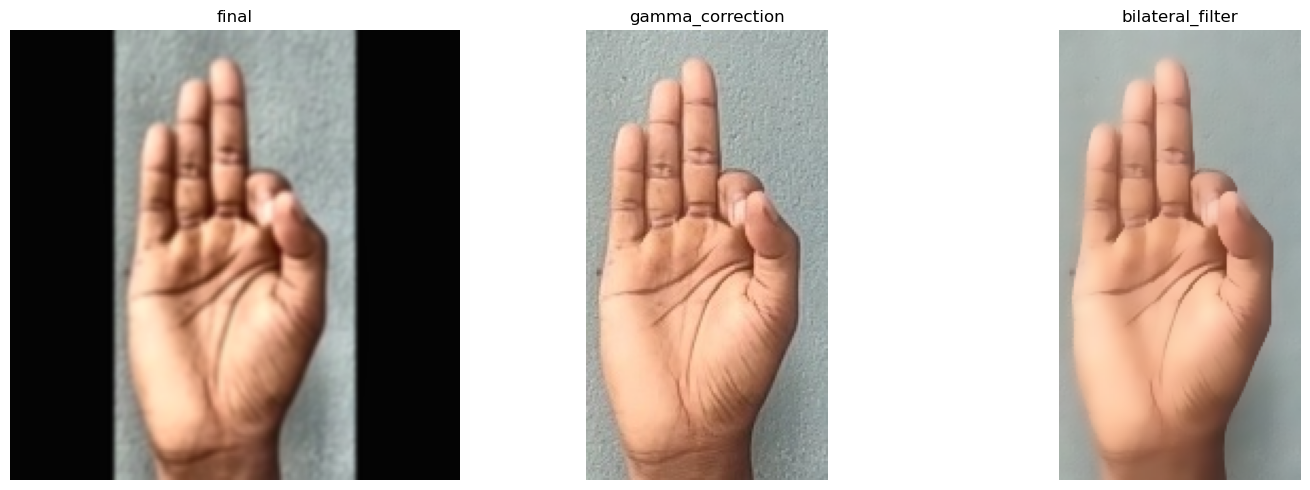

In [4]:
path = "../sample_data/P1_F_68.jpg"
img = cv2.imread(path)
preprocessor = Preprocessor()
results = preprocessor.preprocess(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, img) in zip(axes, results.items()):
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(title)
        ax.axis('off')  
    else:
        ax.set_title(f"{title} (Not Found)")
        ax.axis('off')

plt.tight_layout()
plt.show()

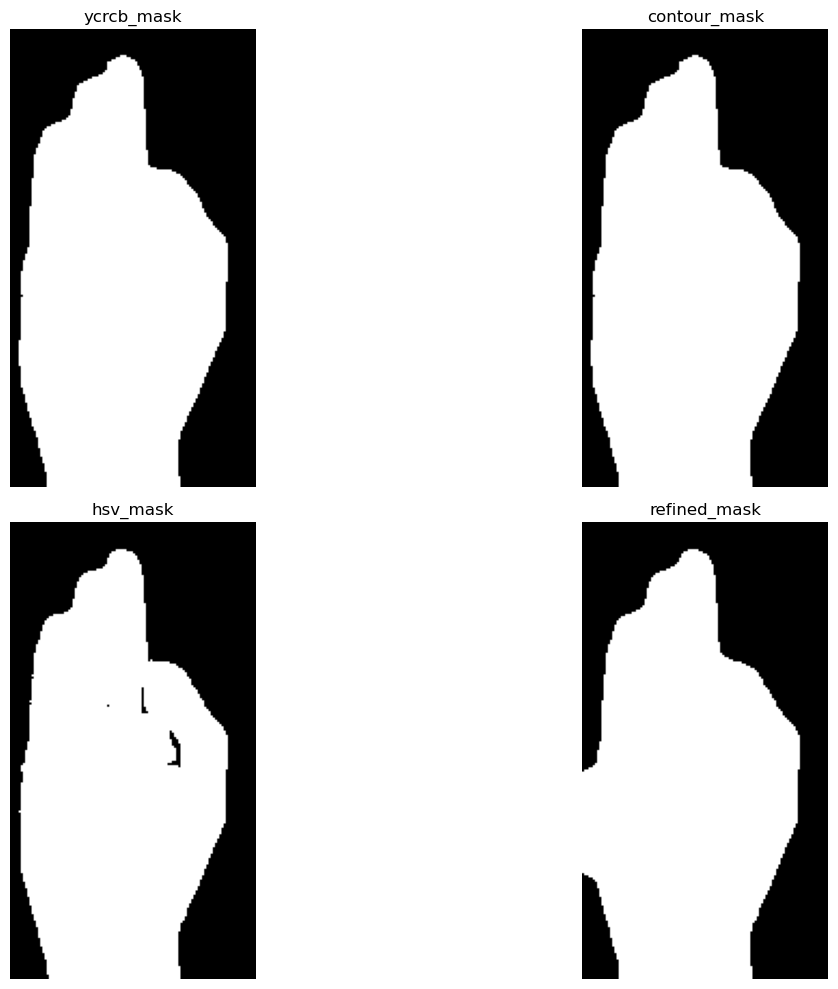

In [12]:
segmentor = Segmentation()
seg_results = segmentor.segment(img)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (name, data) in enumerate(seg_results.items()):
    if name == 'contour':
        continue
    else:
        ax = axes[i]
        if data is not None:
            if len(data.shape) == 2:
                ax.imshow(data, cmap='gray')
            else:
                img_rgb = cv2.cvtColor(data, cv2.COLOR_BGR2RGB)
                ax.imshow(img_rgb)
        ax.set_title(name)
    
    ax.axis('off')
axes[3].axis('off')

plt.tight_layout()
plt.show()

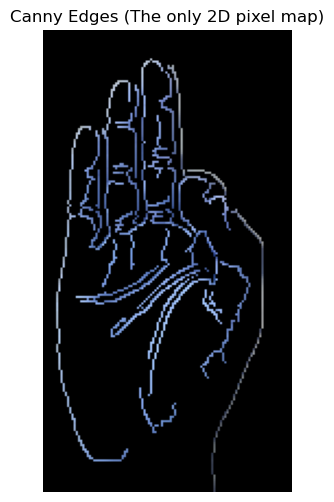

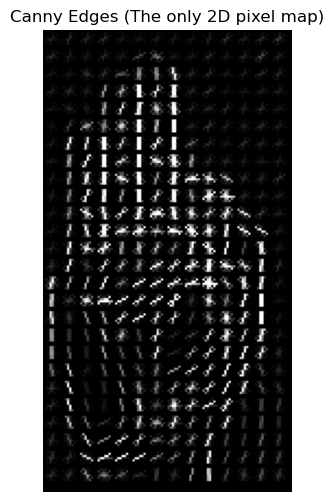

Hu Moments: [0.67601337 1.75985026 3.46891473 4.18483038 8.02179051 5.1824085
 8.58694781]
Feature Vector Shape: (11713,)


In [14]:
feat_extract = FeatureExtraction()
feat_results = feat_extract.extract_all(img, seg_results['contour'], seg_results['ycrcb_mask'])
plt.figure(figsize=(6, 6))
plt.imshow(feat_results['canny_edges'], cmap='gray')
plt.title("Canny Edges (The only 2D pixel map)")
plt.axis('off')
plt.show()
plt.figure(figsize=(6, 6))
plt.imshow(feat_results['hog_img'], cmap='gray')
plt.title("Canny Edges (The only 2D pixel map)")
plt.axis('off')
plt.show()

# For the others, you just use standard Python print() to see the numbers
print(f"Hu Moments: {feat_results['hu']}")
print(f"Feature Vector Shape: {feat_results['features'].shape}")